## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../../Mamoth")
sys.path.insert(0, "../../../../Modules")

from utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [5]:
mosquito_data.nuts2.unique()

array(['κεντρικης μακεδονιας', 'θεσσαλιας', 'κρητης', 'δυτικης ελλαδας'],
      dtype=object)

In [6]:
mosquito_data_nuts2 = mosquito_data.query(f"nuts2 == '{NUTS2_EL}'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [7]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [8]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

# columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
#                 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
#                 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
#                 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week',
#                 'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

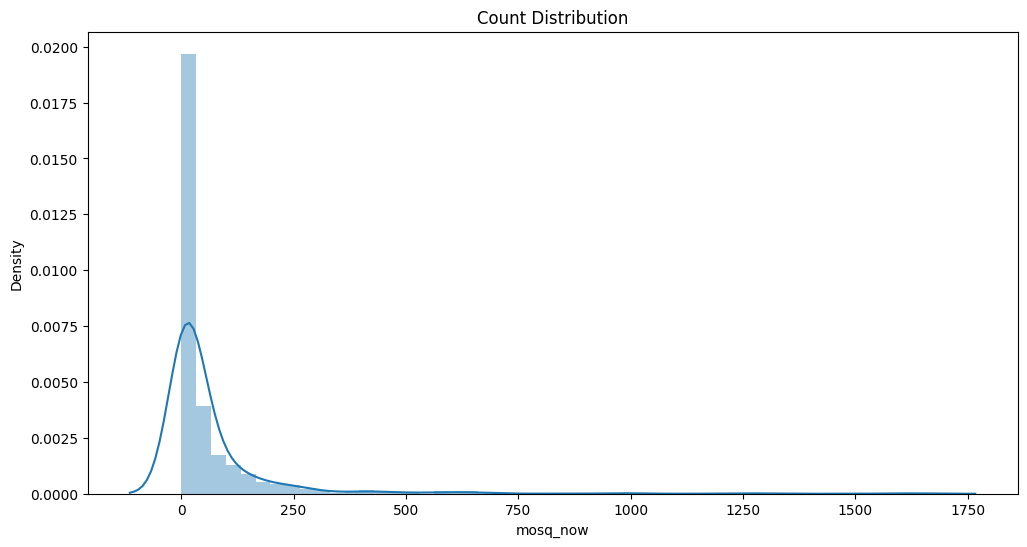

In [9]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [10]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.95)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

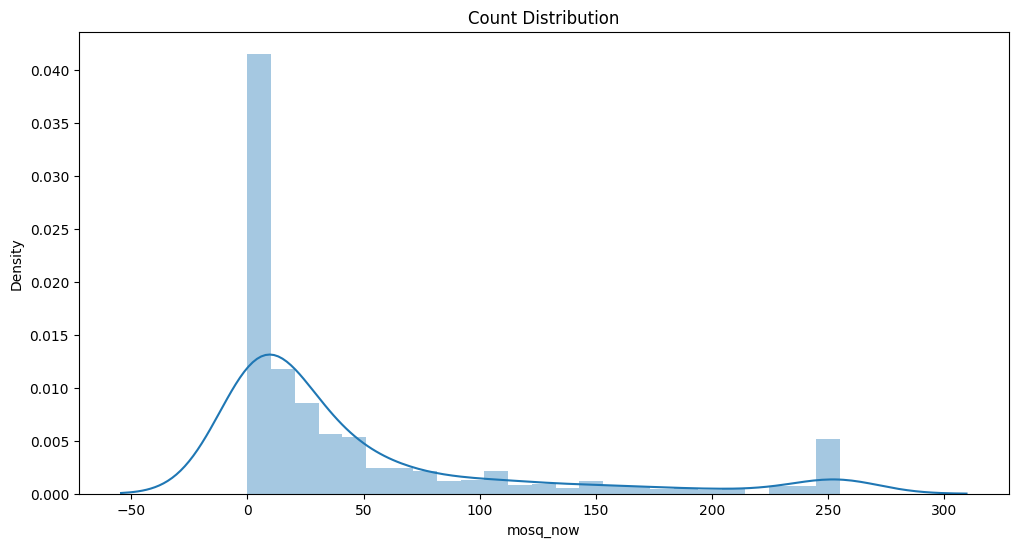

In [11]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<Axes: >

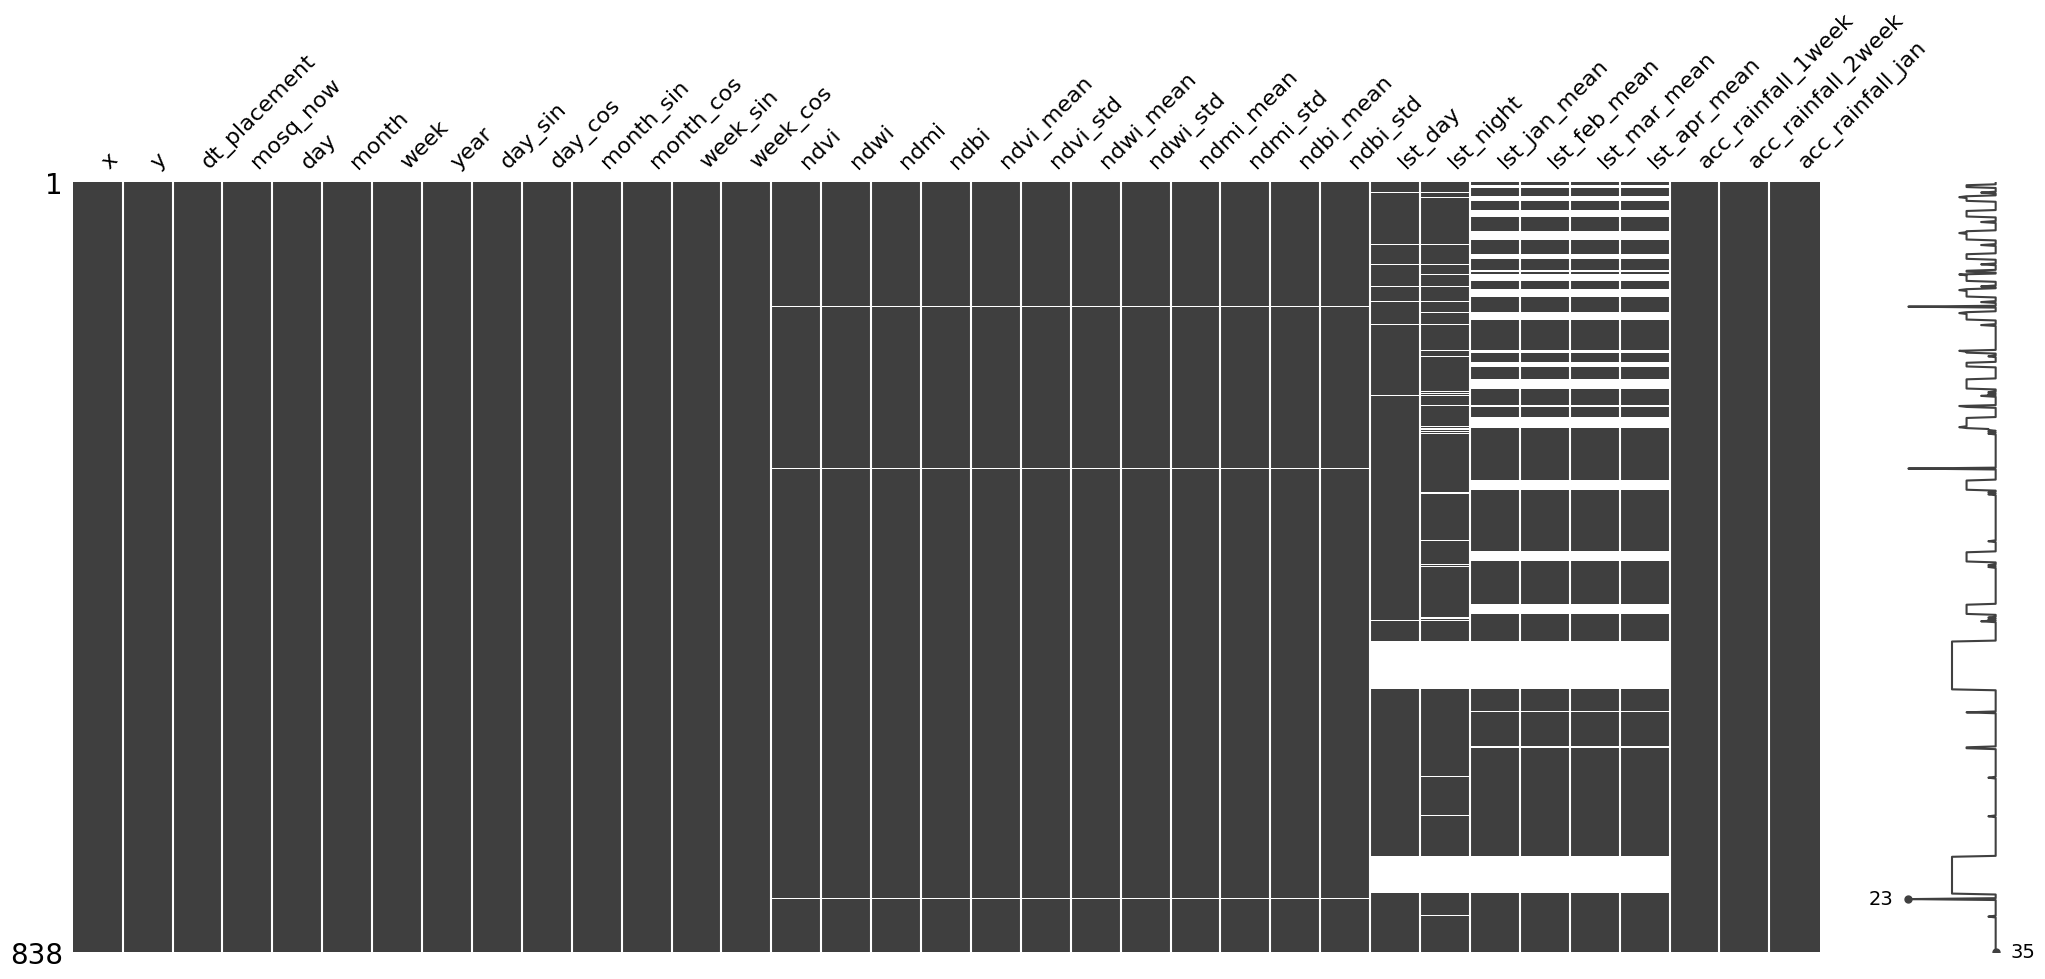

In [12]:
missingno.matrix(mosquito_data_nuts2)

In [13]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

# features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                         'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
#                         'lst_day', 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [14]:
# imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
#                    'lst_day','lst_night']

imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

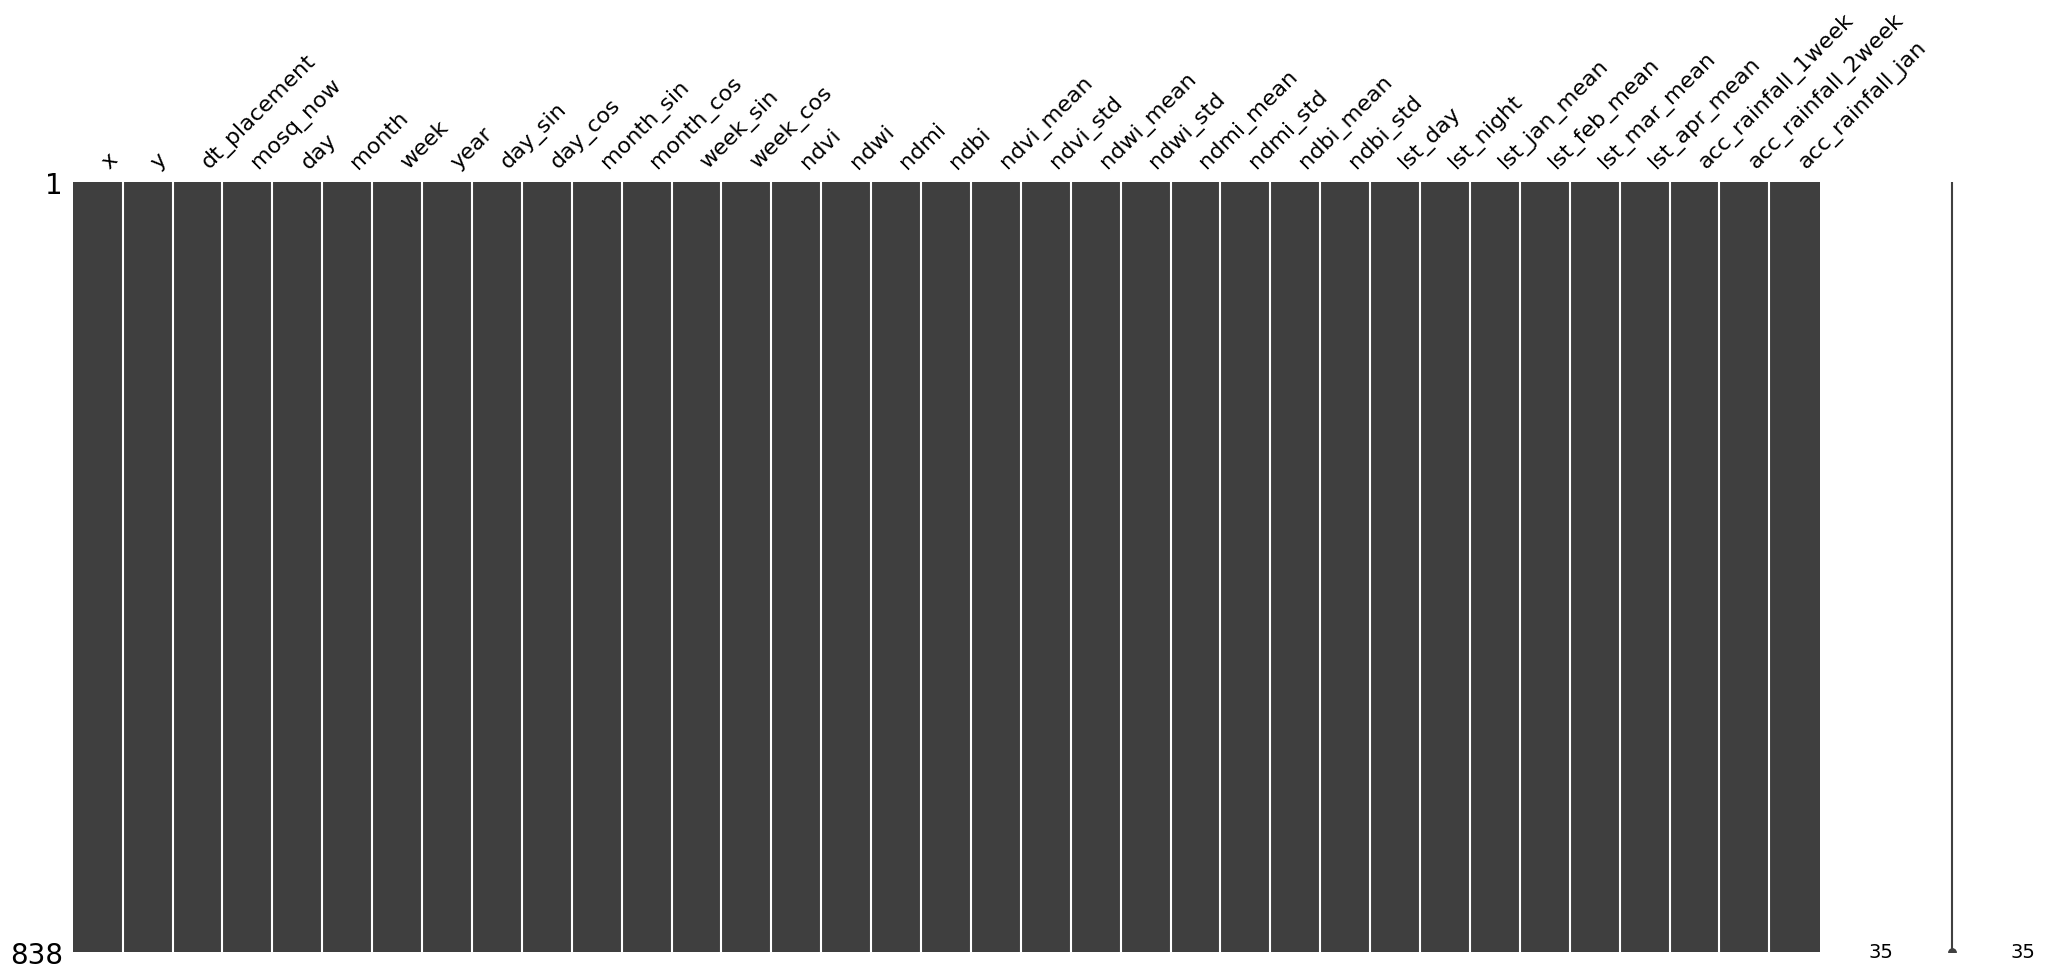

In [15]:
missingno.matrix(mosquito_data_nuts2)

In [16]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [17]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.    16.5  255.15]


In [18]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 41.79371 | Val Loss: 32.19179 | Train Acc: 4.435| Val Acc: 4.028
Epoch 002: | Train Loss: 37.32095 | Val Loss: 29.08301 | Train Acc: 3.541| Val Acc: 3.443
Epoch 003: | Train Loss: 36.04838 | Val Loss: 27.21765 | Train Acc: 3.220| Val Acc: 2.837
Epoch 004: | Train Loss: 34.90155 | Val Loss: 24.85656 | Train Acc: 2.975| Val Acc: 2.564
Epoch 005: | Train Loss: 34.23423 | Val Loss: 23.66324 | Train Acc: 2.881| Val Acc: 2.264
Epoch 006: | Train Loss: 34.20779 | Val Loss: 23.56070 | Train Acc: 2.884| Val Acc: 2.224
Epoch 007: | Train Loss: 33.67248 | Val Loss: 24.39735 | Train Acc: 2.818| Val Acc: 2.362
Epoch 008: | Train Loss: 33.28452 | Val Loss: 24.64461 | Train Acc: 2.768| Val Acc: 2.162
Epoch 009: | Train Loss: 33.03157 | Val Loss: 23.79029 | Train Acc: 2.772| Val Acc: 1.983
Epoch 010: | Train Loss: 32.95853 | Val Loss: 23.41019 | Train Acc: 2.719| Val Acc: 1.966
Epoch 011: | Train Loss: 32.70025 | Val Loss: 23.52475 | Train Acc: 2.699| Val Acc: 1.965
Epoch 012:

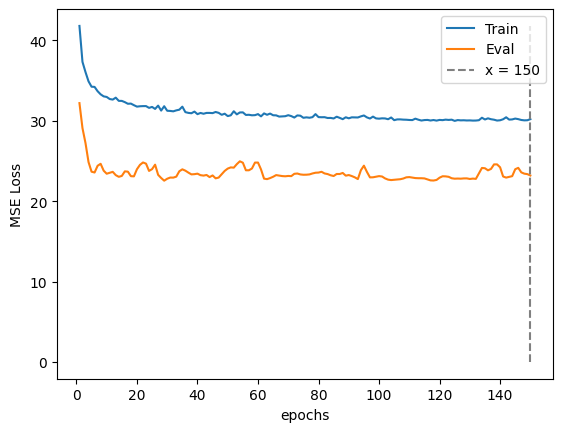

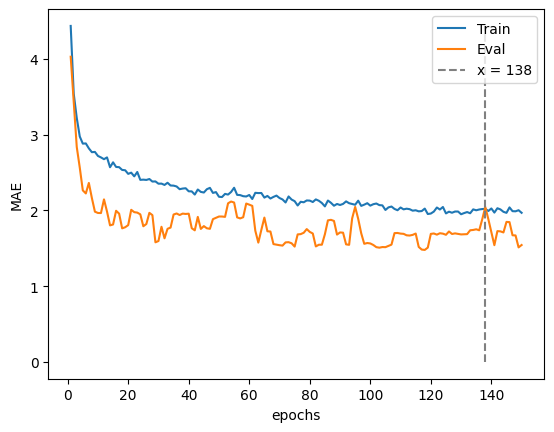

In [19]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [20]:
metrics(train, test, threshold=30)

MAE on train set:  29.099267255188252
min prediction: 1
max prediction: 231

MAE on test set:  29.637022921464578
Error ⩽ 30: 76.34 %
min prediction: 1
max prediction: 277


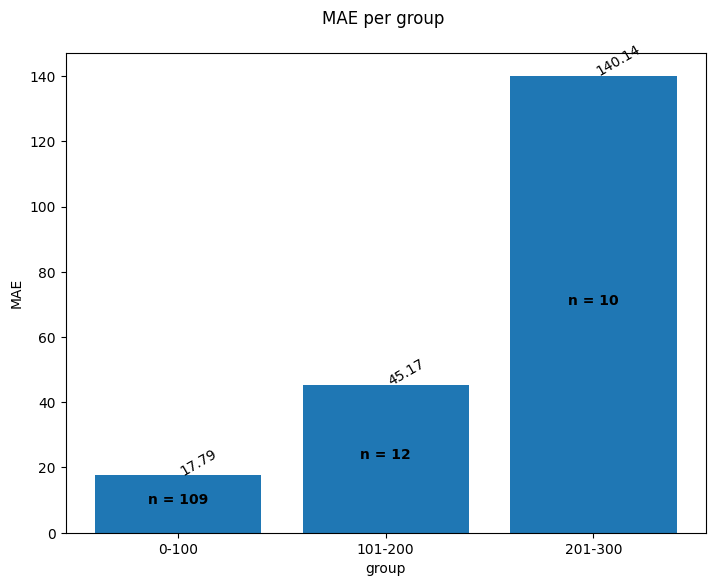

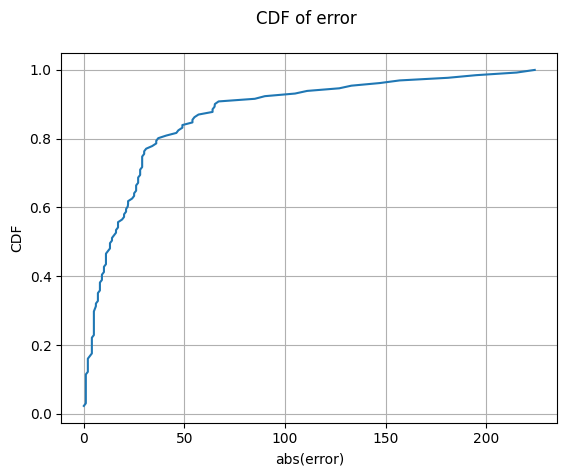

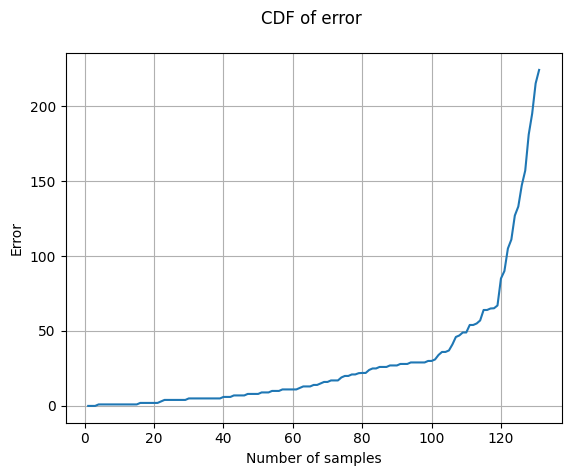

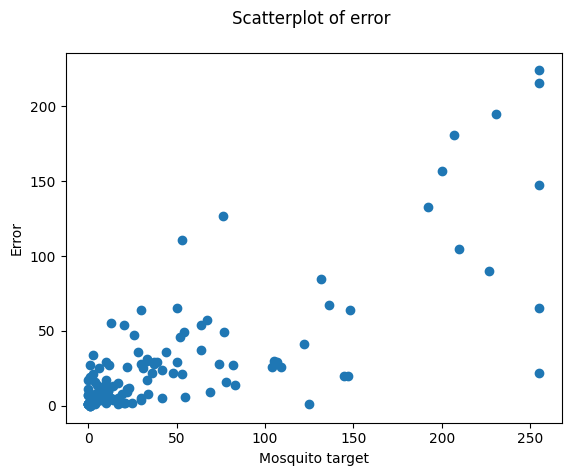

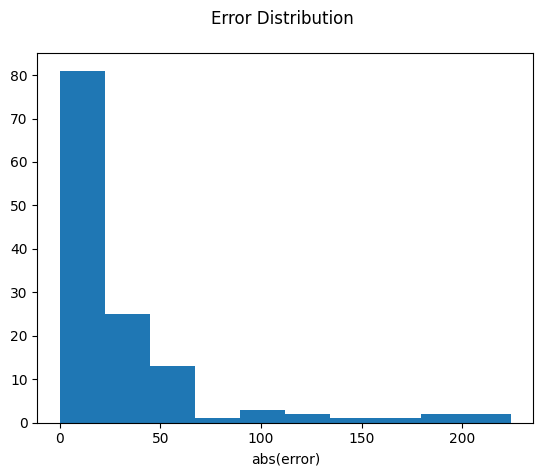

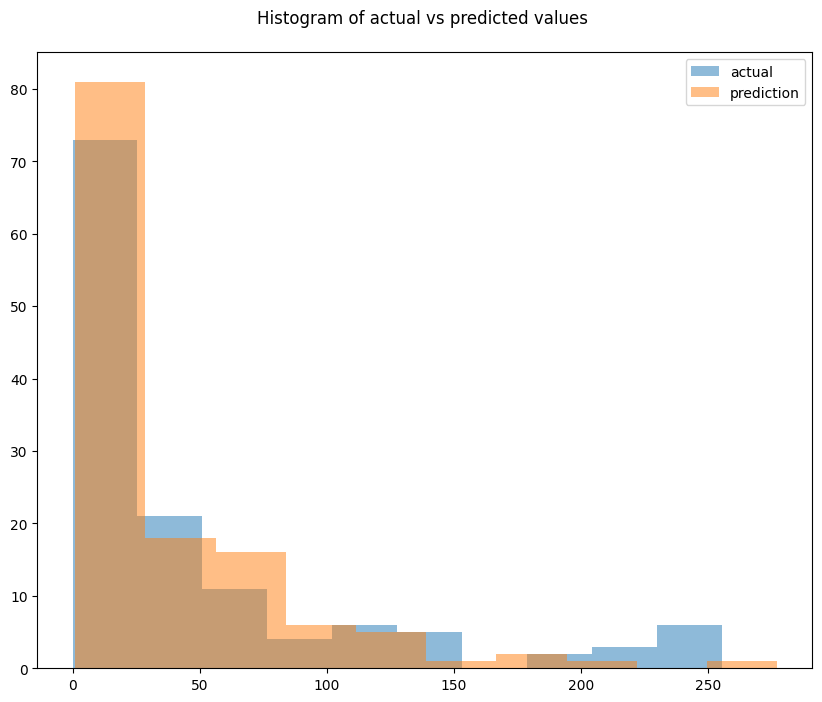

In [21]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.79706 | Val Loss: 0.18336 | Train Acc: 2.403| Val Acc: 0.542
Epoch 002: | Train Loss: 33.00948 | Val Loss: 0.00208 | Train Acc: 2.261| Val Acc: 0.458
Epoch 003: | Train Loss: 33.04118 | Val Loss: 0.08368 | Train Acc: 2.277| Val Acc: 0.542
Epoch 004: | Train Loss: 33.03801 | Val Loss: 0.39681 | Train Acc: 2.290| Val Acc: 0.542
Epoch 005: | Train Loss: 33.12001 | Val Loss: 0.66175 | Train Acc: 2.256| Val Acc: 0.542
Epoch 006: | Train Loss: 32.69527 | Val Loss: 0.45936 | Train Acc: 2.255| Val Acc: 0.542
Epoch 007: | Train Loss: 32.51777 | Val Loss: 0.46496 | Train Acc: 2.185| Val Acc: 0.542
Epoch 008: | Train Loss: 32.53499 | Val Loss: 0.43640 | Train Acc: 2.180| Val Acc: 0.542
Epoch 009: | Train Loss: 32.47813 | Val Loss: 0.33769 | Train Acc: 2.169| Val Acc: 0.542
Epoch 010: | Train Loss: 32.45824 | Val Loss: 0.58835 | Train Acc: 2.190| Val Acc: 0.542
Epoch 011: | Train Loss: 32.31352 | Val Loss: 0.46049 | Train Acc: 2.165| Val Acc: 0.542
Epoch 012: | Train Lo

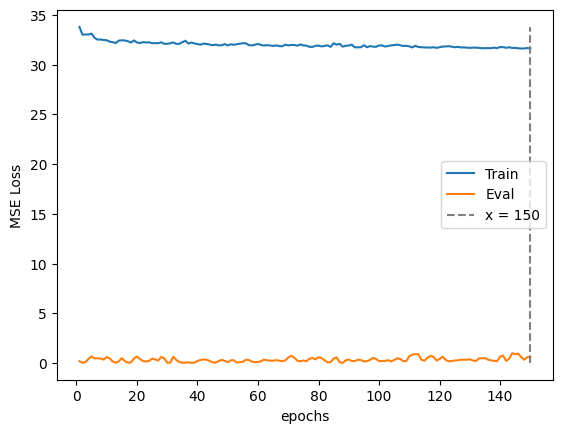

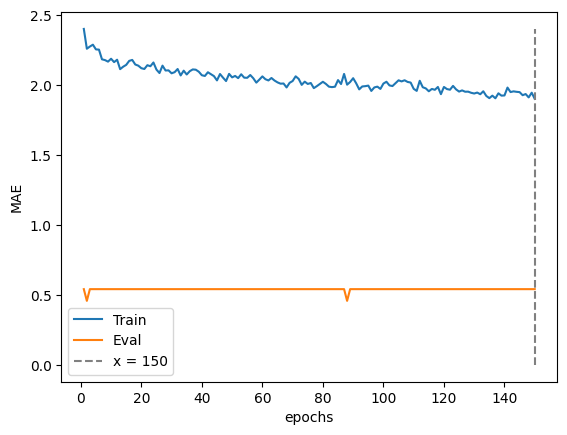

In [22]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [23]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'wb'))